In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [23]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [24]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 11, 
years: 2022, 


In [25]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

dataset = read_data(path)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.701364,12.274545,7.128182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.201406,0.201406,0.201406,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,12,0,0
1,22.07722,41.01522,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.57952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.994259,10.090000,5.898519,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,0.096034,0.096034,0.096034,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,11,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,15,0,0
3,23.95900,40.91196,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.41120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.262667,12.496667,8.028667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,0.036767,0.036767,0.036767,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,4,0,0
4,23.69747,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.92004,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.1328,0.032298,-0.1328,0.018865,0.020253,0.039362,0.020253,11.778056,15.171111,8.385000,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,1.425578,1.425578,1.425578,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,13,0,0


In [26]:
dataset = dataset.query('month >= 5 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [27]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.40326,0.277884,0.135286,-0.119594,-0.135286,0.289617,0.144593,-0.120979,-0.144593,0.033875,0.026132,0.013320,0.026132,23.797273,34.776364,12.818182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.849520,45.860931,513.316999,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,1,84,0
1,22.07722,41.01522,2010-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.57952,0.452498,0.135039,-0.276990,-0.135039,0.445984,0.140292,-0.264097,-0.140292,0.048772,0.040999,0.041759,0.040999,16.598704,23.051111,10.146296,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,13.010832,79.418586,556.232491,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,17,222,0
2,22.89198,40.65603,2010-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.170802,0.062868,-0.101038,-0.062868,0.166419,0.052195,-0.123815,-0.052195,0.085079,0.060522,0.023502,0.060522,22.320000,30.450000,14.190000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,3.478170,46.557858,498.499728,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,6,133,0
3,23.95900,40.91196,2010-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.41120,0.520024,0.242873,-0.253985,-0.242873,0.518081,0.244385,-0.249705,-0.244385,0.043771,0.051783,0.033458,0.051783,18.250000,25.719333,10.780667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,4.135710,17.931808,570.517413,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,26,88,0
4,23.69747,40.49593,2010-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.92004,0.609696,0.317190,-0.243338,-0.317190,0.612239,0.315245,-0.246933,-0.315245,0.039368,0.041644,0.042532,0.041644,16.137222,21.571111,10.703333,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,9.678622,35.371020,502.368716,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,36,138,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7332,22.46197,40.60446,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,478.8,38293.0,86.8,46.40326,0.617572,0.270331,-0.536213,-0.270331,0.594201,0.257659,-0.520467,-0.257659,0.060674,0.063398,0.044711,0.063398,25.904545,32.335455,19.473636,8.278138,-1.417295,15.

In [28]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment',
       'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
       'lc_type1', 'lc_type2', 'lc_type3', 'lc

In [29]:
dataset['lau1'].unique().shape

(38,)

In [30]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,443,250,693,9.45%
1,2011,508,31,539,7.35%
2,2012,513,20,533,7.26%
3,2013,515,21,536,7.31%
4,2014,532,0,532,7.25%
5,2015,532,0,532,7.25%
6,2016,532,0,532,7.25%
7,2017,532,0,532,7.25%
8,2018,463,117,580,7.91%
9,2019,496,53,549,7.48%


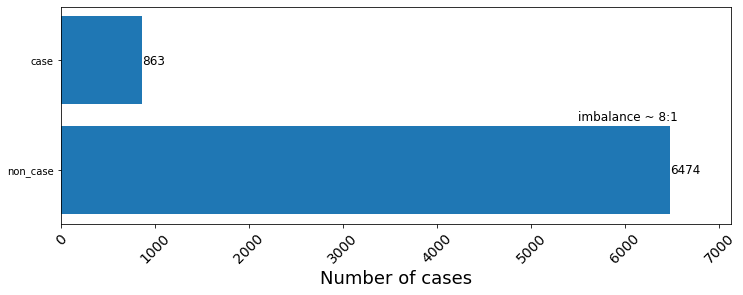

In [31]:
plot_imbalance(dataset)

In [32]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [33]:
r_u = 0
near_u = 0
smote = 0.2
scaler = 'minmax'
weight_multiplier = 1
years_to_remove = [2014, 2015, 2016, 2017]
#years_to_remove = []
features_to_remove = ['day', 'month', 'week', 'year', 'lc_prop1_assessment',
                    'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
                    'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]
features_to_remove = []

In [34]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    X_train.drop(columns = features_to_remove)
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    w0,w1 = calculate_weights(y_train)
    w1 = w1*weight_multiplier

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:6 || ##
Year: 2011 || w0:1, w1:4 || ##
Year: 2012 || w0:1, w1:4 || ##
Year: 2013 || w0:1, w1:4 || ##
Year: 2014 || w0:1, w1:5 || ##
Year: 2015 || w0:1, w1:5 || ##
Year: 2016 || w0:1, w1:5 || ##
Year: 2017 || w0:1, w1:5 || ##
Year: 2018 || w0:1, w1:5 || ##
Year: 2019 || w0:1, w1:4 || ##
Year: 2020 || w0:1, w1:5 || ##
Year: 2021 || w0:1, w1:4 || ##
Year: 2022 || w0:1, w1:6 || ##


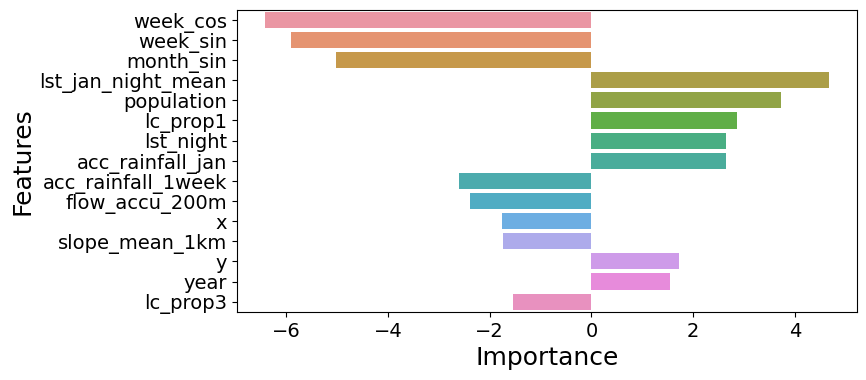

In [35]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

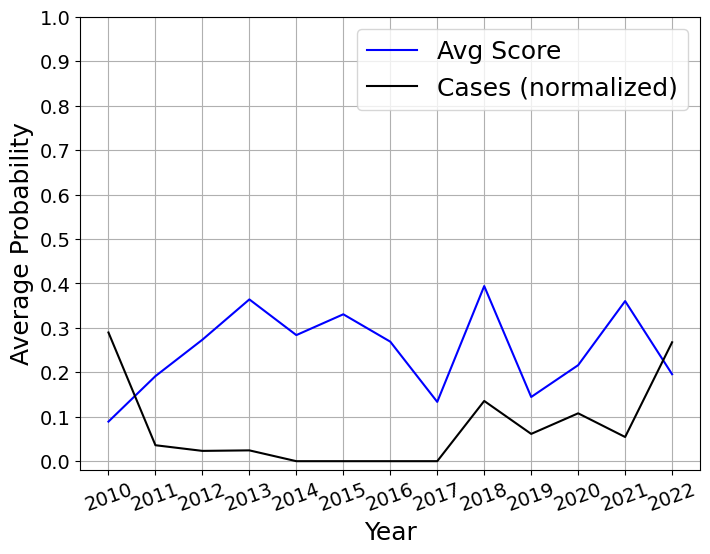

In [36]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

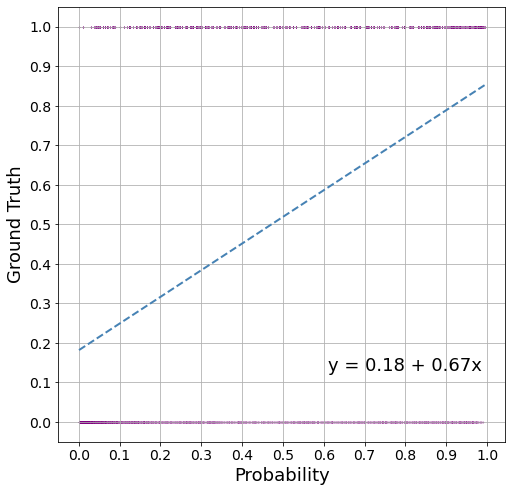

In [37]:
plot_probability_curve(results_test)

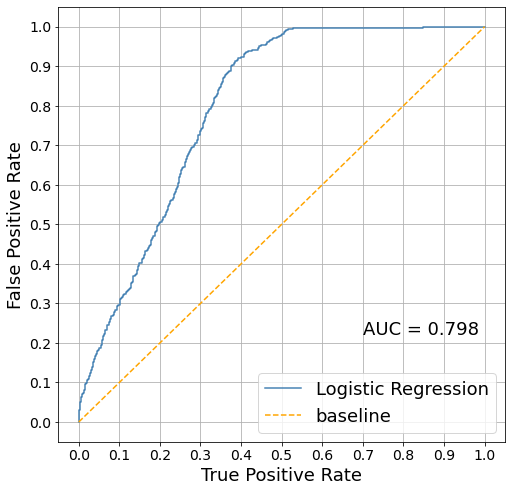

In [38]:
plot_roc_curve(results_test)

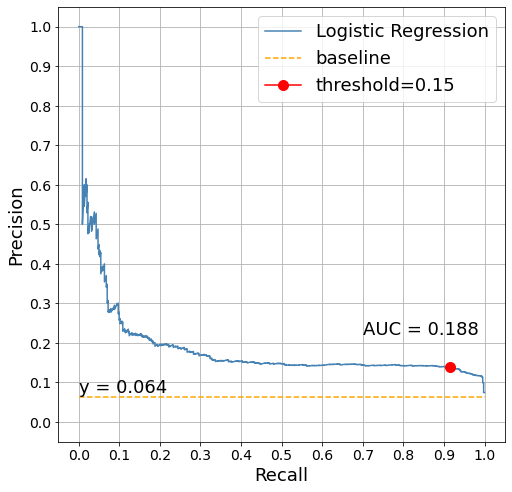

In [39]:
plot_pr_curve(results_test, plot_fbeta = True)

In [40]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 41.12%
Weighted Average: 46.21%

Random Average: 23.67%
Random Weighted Average: 30.64%


In [23]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
3,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/07/2010,1,0,0.11,1,0.00 %,0.0,11.00 %,0.110
...,...,...,...,...,...,...,...,...,...
177,16/09/2022,22,4,2.88,5,80.00 %,0.8,57.60 %,0.576
178,01/10/2022,11,2,1.53,5,40.00 %,0.4,30.60 %,0.306
179,16/10/2022,2,1,0.30,2,50.00 %,0.5,15.00 %,0.150
180,01/11/2022,0,0,0.00,0,NaN,NaN,NaN,NaN


In [24]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,89,18,11.35,26,69.23 %,0.6923,43.65 %,0.4365
1,2011,24,9,3.08,20,45.00 %,0.4500,15.40 %,0.1540
2,2012,19,3,2.28,19,15.79 %,0.1579,12.00 %,0.1200
3,2013,17,7,2.36,17,41.18 %,0.4118,13.88 %,0.1388
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,69,14,8.98,34,41.18 %,0.4118,26.41 %,0.2641
9,2019,36,4,5.06,24,16.67 %,0.1667,21.08 %,0.2108


In [25]:
results_test

,x,y,lau1,day,month,year,case,score
0,22.36451,40.79600,πελλας,16,8,2018,1,9.936615e-01
1,22.36451,40.79600,πελλας,16,8,2013,1,9.914227e-01
2,22.46197,40.60446,αλεξανδρειας,16,8,2021,1,9.903412e-01
3,22.72632,40.61725,δελτα,16,8,2018,1,9.902314e-01
4,22.36451,40.79600,πελλας,1,8,2013,0,9.900887e-01
...,...,...,...,...,...,...,...,...
6911,22.47539,40.12020,διου ολυμπου,1,5,2010,0,8.374365e-07
6912,23.69747,40.49593,αριστοτελη,1,5,2011,0,8.063633e-07
6913,22.47539,40.12020,διου ολυμπου,1,5,2017,0,6.064692e-07
6914,23.87955,40.08302,σιθωνιας,1,5,2010,0,5.489874e-07


In [26]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [27]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.1654,0.8190,0.7045,0.6966,0.6971,0.2753
1,2011,24.0,0.3365,0.8256,0.1285,0.9583,0.6945,0.2714
2,2012,19.0,0.4342,0.7934,0.0823,1.0000,0.6037,0.4933
3,2013,17.0,0.5056,0.7553,0.0632,1.0000,0.5342,0.7514
4,2014,0.0,0.4323,0.5677,0.0000,0.0000,0.0000,0.5227
5,2015,0.0,0.4737,0.5263,0.0000,0.0000,0.0000,0.6790
6,2016,0.0,0.4135,0.5865,0.0000,0.0000,0.0000,0.5003
7,2017,0.0,0.2500,0.7500,0.0000,0.0000,0.0000,0.1942
8,2018,69.0,0.5075,0.7746,0.2519,0.9855,0.8413,0.7126
9,2019,36.0,0.2688,0.7730,0.1958,0.7778,0.6620,0.2451


In [28]:
results_test

,x,y,lau1,day,month,year,case,score
0,22.36451,40.79600,πελλας,16,8,2018,1,9.936615e-01
1,22.36451,40.79600,πελλας,16,8,2013,1,9.914227e-01
2,22.46197,40.60446,αλεξανδρειας,16,8,2021,1,9.903412e-01
3,22.72632,40.61725,δελτα,16,8,2018,1,9.902314e-01
4,22.36451,40.79600,πελλας,1,8,2013,0,9.900887e-01
...,...,...,...,...,...,...,...,...
6911,22.47539,40.12020,διου ολυμπου,1,5,2010,0,8.374365e-07
6912,23.69747,40.49593,αριστοτελη,1,5,2011,0,8.063633e-07
6913,22.47539,40.12020,διου ολυμπου,1,5,2017,0,6.064692e-07
6914,23.87955,40.08302,σιθωνιας,1,5,2010,0,5.489874e-07


In [29]:
results_test[['x', 'y', 'day', 'month', 'year']].value_counts()

x         y         day  month  year
21.93869  40.79699  1    5      2010    1
23.19403  40.32484  1    9      2015    1
                         10     2013    1
                                2012    1
                                2011    1
                                       ..
22.72632  40.61725  16   7      2010    1
                         6      2022    1
                                2021    1
                                2020    1
23.95900  40.91196  16   11     2022    1
Length: 6916, dtype: int64

In [30]:
results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [31]:
scalers = {'minmax': MinMaxScaler(),
               'standard': StandardScaler(),
               'robust': RobustScaler(),
               'abs': MaxAbsScaler()}

data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
X_train.drop(columns = features_to_remove)
y_train = data_train['case']

if(r_u != 0):
    nan_index = []
    zero_index = []
        
    for index, row in X_train.iterrows():
        if row.isnull().values.any():
            nan_index.append(index)
            if y_train.iloc[index] == 0:
                zero_index.append(index)
            
    nan_set = set(nan_index)
    zero_set = set(zero_index)
        
    intersection = list(nan_set.intersection(zero_set))
    sampling_size = math.ceil(len(intersection) * r_u)
    removed = random.sample(intersection, sampling_size)
        
    X_train = X_train.drop(index = removed, axis = 1)
    y_train = y_train.drop(index = removed, axis = 1)

scaler = scalers.get(scaler, MinMaxScaler())
X_train = scaler.fit_transform(X_train)
    
imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0

if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)

if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

In [32]:
w0,w1 = calculate_weights(y_train)
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

trained_model = train_lin_model(model, X_train, y_train)

In [33]:
trained_model

LogisticRegression(class_weight={0.0: 1, 1.0: 5}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [34]:
pickle.dump(trained_model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler.pkl', 'wb'))